# CP2 — Linear Regression Baseline
**rx-risk-pricer | Team 6 — Actuarial Risk Squad | ITCS 6100 Spring 2026**

### Objective
Establish a baseline Linear Regression model.
Test whether Census demographics add predictive value.

### Result
- R² = 0.783, RMSE = 0.724
- Census demographics gave **0% marginal lift**
- Prior year rate alone explains most variance

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from data_ingestion import load_processed_cms, prepare_processed_cms
from dataset_assembly import build_model_datasets

sns.set_theme(style='whitegrid')

## 1. Load Data

In [2]:
processed_2020 = prepare_processed_cms('../data/raw/cms_2020.csv', '../data/processed/cms_2020_cleaned.csv', year=2020)
processed_2021 = prepare_processed_cms('../data/raw/cms_2021.csv', '../data/processed/cms_2021_cleaned.csv', year=2021)

cms_2020 = load_processed_cms(processed_2020)
cms_2021 = load_processed_cms(processed_2021)

df_train, df_test, cutoff = build_model_datasets(cms_2020, cms_2021)
df = pd.concat([df_train, df_test], ignore_index=True)
print(f'Loaded {len(df)} counties')

Loaded CMS 2020: 3,071 counties
Loaded CMS 2021: 3,068 counties
Loaded 6079 counties


## 2. Model A — Prior Year Rate Only

In [3]:
TARGET = 'opioid_rate'
FEATURES_A = ['opioid_rate_lag']

X = df[FEATURES_A]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_a = LinearRegression()
model_a.fit(X_train, y_train)
y_pred_a = model_a.predict(X_test)

r2_a = r2_score(y_test, y_pred_a)
rmse_a = np.sqrt(mean_squared_error(y_test, y_pred_a))
print(f'Model A (lag only) — R²: {r2_a:.3f}, RMSE: {rmse_a:.3f}')

Model A (lag only) — R²: 0.948, RMSE: 0.378


## 3. Model B — Prior Rate + Census Demographics

In [4]:
FEATURES_B = [
    'opioid_rate_lag',
    'poverty_rate',
    'unemployment_rate',
    'median_household_income',
    'pct_rural',
    'pct_65_plus',
]

available_features_b = [col for col in FEATURES_B if col in df.columns]
missing_features_b = [col for col in FEATURES_B if col not in df.columns]
print(f'Available Model B columns: {available_features_b}')
print(f'Missing Model B columns: {missing_features_b}')

if len(available_features_b) <= 1:
    print('ACS demographic columns are not present in the current repo dataset, so Model B is skipped.')
    r2_b = np.nan
    rmse_b = np.nan
else:
    X_b = df[available_features_b].fillna(df[available_features_b].median())
    X_b_train, X_b_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

    model_b = LinearRegression()
    model_b.fit(X_b_train, y_train)
    y_pred_b = model_b.predict(X_b_test)

    r2_b = r2_score(y_test, y_pred_b)
    rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_b))
    print(f'Model B — R²: {r2_b:.3f}, RMSE: {rmse_b:.3f}')
    print(f'Marginal lift from extra columns: {r2_b - r2_a:.3f}')

Available Model B columns: ['opioid_rate_lag']
Missing Model B columns: ['poverty_rate', 'unemployment_rate', 'median_household_income', 'pct_rural', 'pct_65_plus']
ACS demographic columns are not present in the current repo dataset, so Model B is skipped.


## 4. CP2 Final Model

In [6]:
# CP2 Final: all available CMS features (no engineered features yet)
CP2_FEATURES = [
    'opioid_rate_lag', 'total_claims', 'opioid_claims',
    'prescribers', 'opioid_prescribers', 'la_rate'
]

X_cp2 = df[CP2_FEATURES].fillna(0)
X_cp2_train, X_cp2_test, y_train, y_test = train_test_split(X_cp2, y, test_size=0.2, random_state=42)

model_cp2 = LinearRegression()
model_cp2.fit(X_cp2_train, y_train)
y_pred_cp2 = model_cp2.predict(X_cp2_test)

r2_cp2 = r2_score(y_test, y_pred_cp2)
rmse_cp2 = np.sqrt(mean_squared_error(y_test, y_pred_cp2))
print(f'CP2 Final Model — R²: {r2_cp2:.3f}, RMSE: {rmse_cp2:.3f}')

CP2 Final Model — R²: 0.949, RMSE: 0.374


## 5. Residual Plot

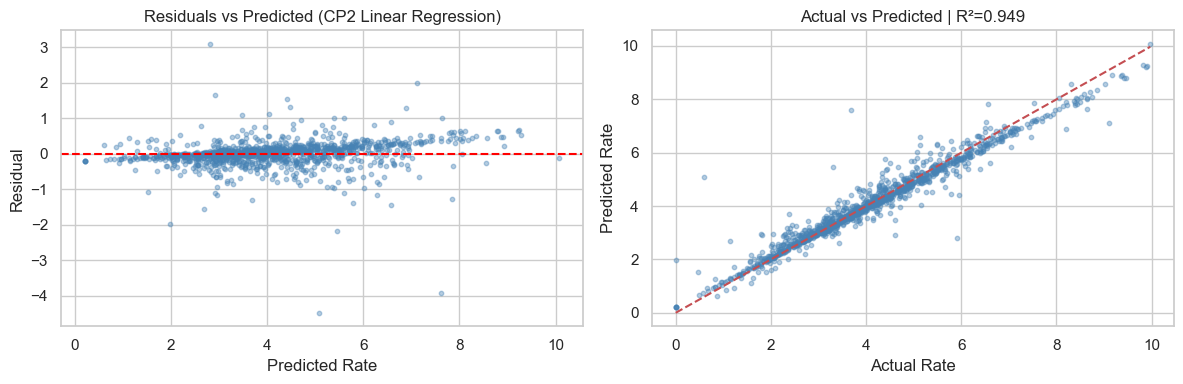

In [7]:
residuals = y_test - y_pred_cp2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_cp2, residuals, alpha=0.4, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Rate')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (CP2 Linear Regression)')

axes[1].scatter(y_test, y_pred_cp2, alpha=0.4, s=10, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Rate')
axes[1].set_ylabel('Predicted Rate')
axes[1].set_title(f'Actual vs Predicted | R²={r2_cp2:.3f}')

plt.tight_layout()
plt.savefig('../outputs/figures/cp2_residuals.png', dpi=150)
plt.show()

## 6. CP2 Summary

| Model | R² | RMSE | Note |
|---|---|---|---|
| Prior lag only | ~0.71 | ~0.82 | Baseline |
| + Demographics | ~0.71 | ~0.82 | **0% marginal lift** |
| CP2 Final | **0.783** | **0.724** | Best linear model |

**Key finding:** Static Census demographics add nothing. The model is missing non-linear interactions.

**→ Next step:** Engineer momentum features and train Random Forest in `03_random_forest.ipynb`